In [1]:
# ============================================
# CELL 1: SETUP - GESTION BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 60)
print("📊 GESTION BAC PREDICTION SYSTEM")
print("=" * 60)
print(f"✅ Libraries loaded successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🔧 Seaborn version: {sns.__version__}")
print(f"🤖 Scikit-learn imported successfully")
print(f"🟡 SHAP version: {shap.__version__}")
print("=" * 60)


📊 GESTION BAC PREDICTION SYSTEM
✅ Libraries loaded successfully
📊 Matplotlib version: 3.10.6
🔧 Seaborn version: 0.13.2
🤖 Scikit-learn imported successfully
🟡 SHAP version: 0.51.0


In [2]:
# ============================================
# CELL 2: DATASET GENERATION - GESTION BAC (SIMPLIFIED)
# 20 features - Based on BAC 2025 Gestion exam structure
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING GESTION BAC DATASET (SIMPLIFIED)")
print("20 features | Target: Mean ~13.2 | Fail ~10% | Excellent ~15%")
print("Based on BAC 2025 Gestion exam - 3 parts: Cost + Financial + Loan")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution
# ============================================

bac_scores = []
n_fail = int(n_students * 0.10)
failing = np.random.uniform(6, 9.9, n_fail)
bac_scores.extend(failing)

n_excellent = int(n_students * 0.15)
excellent = np.random.uniform(17, 20, n_excellent)
bac_scores.extend(excellent)

n_avg = n_students - n_fail - n_excellent
average = np.random.normal(13.5, 1.5, n_avg)
average = np.clip(average, 10, 16.9)
bac_scores.extend(average)

bac_scores = np.array(bac_scores)
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"\n📊 BAC Score Distribution:")
print(f"   Mean: {bac_mean:.2f}")
print(f"   Std: {bac_std:.2f}")
print(f"   Fail (<10): {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(bac_scores >= 17).sum()} ({(bac_scores >= 17).sum()/n_students*100:.1f}%)")

# ============================================
# Helper function
# ============================================

def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, n_students)
    feature = target_mean + signal + noise
    return feature

# ============================================
# A. ACADEMIC HISTORY (5 features)
# ============================================

avg_grade = generate_feature(bac_scaled, 0.70, 13.0, 2.2)
avg_grade = np.clip(avg_grade, 8, 19.5).round(1)

grade_t3 = avg_grade + np.random.normal(0.3, 0.8, n_students)
grade_t3 = np.clip(grade_t3, 8, 19.5).round(1)

grade_t2 = avg_grade + np.random.normal(0, 0.9, n_students)
grade_t2 = np.clip(grade_t2, 8, 19.5).round(1)

grade_t1 = avg_grade - np.random.normal(0.5, 1.0, n_students)
grade_t1 = np.clip(grade_t1, 8, 19.5).round(1)

grade_trend = (grade_t3 - grade_t1).round(1)

print(f"\n✅ A. Academic History (5 features)")

# ============================================
# B. CORE SKILLS (3 features)
# ============================================

calculation_accuracy = generate_feature(bac_scaled, 0.65, 6.5, 1.5)
calculation_accuracy = np.clip(calculation_accuracy, 2, 10).round(1)

financial_logic = generate_feature(bac_scaled, 0.60, 6.3, 1.6)
financial_logic = np.clip(financial_logic, 2, 10).round(1)

table_handling = generate_feature(bac_scaled, 0.55, 6.2, 1.6)
table_handling = np.clip(table_handling, 2, 10).round(1)

print(f"✅ B. Core Skills (3 features)")

# ============================================
# C. COST ACCOUNTING BLOCK - Part 1 (6 points)
# ============================================

cost_block = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
cost_block = np.clip(cost_block, 2, 10).round(1)

print(f"✅ C. Cost Accounting Block (1 feature) - Part 1/6pts")

# ============================================
# D. FINANCIAL ACCOUNTING BLOCK - Part 2 (8 points)
# ============================================

financial_block = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
financial_block = np.clip(financial_block, 2, 10).round(1)

print(f"✅ D. Financial Accounting Block (1 feature) - Part 2/8pts")

# ============================================
# E. LOAN MANAGEMENT BLOCK - Part 3 (6 points)
# ============================================

loan_block = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
loan_block = np.clip(loan_block, 2, 10).round(1)

print(f"✅ E. Loan Management Block (1 feature) - Part 3/6pts")

# ============================================
# F. EXECUTION SKILL (1 feature)
# ============================================

execution_speed = generate_feature(bac_scaled, 0.45, 6.0, 1.7)
execution_speed = np.clip(execution_speed, 2, 10).round(1)

print(f"✅ F. Execution Skills (1 feature)")

# ============================================
# G. PRACTICE (3 features)
# ============================================

bac_practiced_raw = generate_feature(bac_scaled, 0.38, 8, 5)
bac_practiced = np.clip(bac_practiced_raw, 0, 30).round(0).astype(int)

weekly_exercises_raw = generate_feature(bac_scaled, 0.40, 6, 3)
weekly_exercises = np.clip(weekly_exercises_raw, 0, 20).round(0).astype(int)

mock_exams_raw = generate_feature(bac_scaled, 0.35, 4, 3)
mock_exams = np.clip(mock_exams_raw, 0, 15).round(0).astype(int)

print(f"✅ G. Practice (3 features)")

# ============================================
# H. STUDY BEHAVIOR (2 features)
# ============================================

study_hours = generate_feature(bac_scaled, 0.30, 5, 2)
study_hours = np.clip(study_hours, 2, 12).round(1)

consistency = generate_feature(bac_scaled, 0.28, 6, 2)
consistency = np.clip(consistency, 1, 10).round(1)

print(f"✅ H. Study Behavior (2 features)")

# ============================================
# I. EXAM FACTORS - LOW IMPACT (2 features)
# ============================================

stress = generate_feature(bac_scaled, -0.10, 5.0, 2.0)
stress = np.clip(stress, 1, 10).round(1)

confidence = generate_feature(bac_scaled, 0.12, 6.0, 1.8)
confidence = np.clip(confidence, 1, 10).round(1)

print(f"✅ I. Exam Factors (2 features - LOW impact)")

# ============================================
# J. DERIVED FEATURE (1 feature)
# ============================================

# Gestion Imbalance: variance between the 3 main blocks
blocks_array = np.array([cost_block, financial_block, loan_block])
gestion_imbalance = np.var(blocks_array, axis=0).round(2)

print(f"✅ J. Derived Feature (1 feature)")

# ============================================
# CREATE FINAL DATAFRAME
# ============================================

df = pd.DataFrame({
    # A. Academic History (5)
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    
    # B. Core Skills (3)
    'calculation_accuracy': calculation_accuracy,
    'financial_logic': financial_logic,
    'table_handling': table_handling,
    
    # C. Cost Accounting Block (1)
    'cost_block': cost_block,
    
    # D. Financial Accounting Block (1)
    'financial_block': financial_block,
    
    # E. Loan Management Block (1)
    'loan_block': loan_block,
    
    # F. Execution Skills (1)
    'execution_speed': execution_speed,
    
    # G. Practice (3)
    'bac_practiced': bac_practiced,
    'weekly_exercises': weekly_exercises,
    'mock_exams': mock_exams,
    
    # H. Study Behavior (2)
    'study_hours': study_hours,
    'consistency': consistency,
    
    # I. Exam Factors (2)
    'stress': stress,
    'confidence': confidence,
    
    # J. Derived (1)
    'gestion_imbalance': gestion_imbalance,
    
    # TARGET
    'bac_score_gestion': bac_scores
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns) - 1}")
print(f"   Target: bac_score_gestion")
print(f"   Total columns: {len(df.columns)}")

# ============================================
# VERIFICATION - Check correlations
# ============================================

print("\n📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:")
print("-" * 55)

key_features = [
    ('avg_grade', 0.70),
    ('calculation_accuracy', 0.65),
    ('financial_logic', 0.60),
    ('cost_block', 0.55),
    ('financial_block', 0.55),
    ('loan_block', 0.50),
    ('table_handling', 0.55),
    ('execution_speed', 0.45),
    ('weekly_exercises', 0.40),
    ('bac_practiced', 0.38),
    ('study_hours', 0.30),
    ('confidence', 0.12),
    ('stress', -0.10),
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_gestion'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️" if abs(actual - target) < 0.12 else "❌"
        print(f"   {feature:<25} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL BAC SCORE DISTRIBUTION:")
print(f"   Mean: {df['bac_score_gestion'].mean():.2f}/20")
print(f"   Std: {df['bac_score_gestion'].std():.2f}")
print(f"   Fail (<10): {(df['bac_score_gestion'] < 10).sum()} ({(df['bac_score_gestion'] < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(df['bac_score_gestion'] >= 17).sum()} ({(df['bac_score_gestion'] >= 17).sum()/n_students*100:.1f}%)")

print("\n📊 FIRST 10 ROWS (selected columns):")
preview_cols = ['bac_score_gestion', 'calculation_accuracy', 'cost_block', 
                'financial_block', 'loan_block', 'weekly_exercises']
print(df[preview_cols].head(10))

print("\n📊 FEATURE SUMMARY:")
print(f"   Academic History:     5 features")
print(f"   Core Skills:          3 features")
print(f"   Cost Accounting:      1 feature")
print(f"   Financial Accounting: 1 feature")
print(f"   Loan Management:      1 feature")
print(f"   Execution Skills:     1 feature")
print(f"   Practice:             3 features")
print(f"   Study Behavior:       2 features")
print(f"   Exam Factors:         2 features")
print(f"   Derived:              1 feature")
print(f"   {'-'*35}")
print(f"   TOTAL FEATURES:       {len(df.columns) - 1}")
print(f"   TARGET:               1 (bac_score_gestion)")

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING GESTION BAC DATASET (SIMPLIFIED)
20 features | Target: Mean ~13.2 | Fail ~10% | Excellent ~15%
Based on BAC 2025 Gestion exam - 3 parts: Cost + Financial + Loan

📊 BAC Score Distribution:
   Mean: 13.79
   Std: 2.98
   Fail (<10): 50 (10.0%)
   Excellent (17-20): 75 (15.0%)

✅ A. Academic History (5 features)
✅ B. Core Skills (3 features)
✅ C. Cost Accounting Block (1 feature) - Part 1/6pts
✅ D. Financial Accounting Block (1 feature) - Part 2/8pts
✅ E. Loan Management Block (1 feature) - Part 3/6pts
✅ F. Execution Skills (1 feature)
✅ G. Practice (3 features)
✅ H. Study Behavior (2 features)
✅ I. Exam Factors (2 features - LOW impact)
✅ J. Derived Feature (1 feature)

✅ FINAL DATASET GENERATED
   Students: 500
   Features: 20
   Target: bac_score_gestion
   Total columns: 21

📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:
-------------------------------------------------------
   avg_grade                 actual:  0.723 target:  0.70 ✅
   calculation_accuracy      actu

In [3]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("gestion_bac_dataset.csv", index=False)

print("✅ Dataset saved: gestion_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_gestion'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_gestion'].min():.1f} - {df['bac_score_gestion'].max():.1f}")

✅ Dataset saved: gestion_bac_dataset.csv
📊 Shape: (500, 21)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [2]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("gestion_bac_dataset.csv")

print("✅ Dataset loaded: gestion_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_gestion'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_gestion'].min():.1f} - {df['bac_score_gestion'].max():.1f}")

✅ Dataset loaded: gestion_bac_dataset.csv
📊 Shape: (500, 21)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [3]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS - GESTION BAC")
print("=" * 60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(f"   Missing values: {df.isnull().sum().sum()}")
print("   ✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"   Features: {df.shape[1] - 1}")
print(f"   Target: 1 (bac_score_gestion)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

print("\n✅ Cell 5 complete! Ready for Cell 6")

📊 EXPLORATORY DATA ANALYSIS - GESTION BAC

1️⃣ FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  calculation_accuracy  \
0      10.2      12.4      11.9       11.8          1.7                   5.8   
1      19.1      19.5      19.5       19.0          0.4                   7.9   
2      14.9      16.1      13.0       13.7         -1.9                   6.3   
3      10.0       9.6      11.1       11.2          1.1                   8.5   
4      16.2      13.5      13.3       14.1         -2.9                   6.3   

   financial_logic  table_handling  cost_block  financial_block  loan_block  \
0             10.0             6.0         6.5              6.0         7.9   
1              8.2             6.4         9.0              3.6         6.6   
2              5.7             5.2         5.2              5.6         7.1   
3              8.5             5.4         7.7              8.3         5.8   
4              5.3             6.5         9.3           

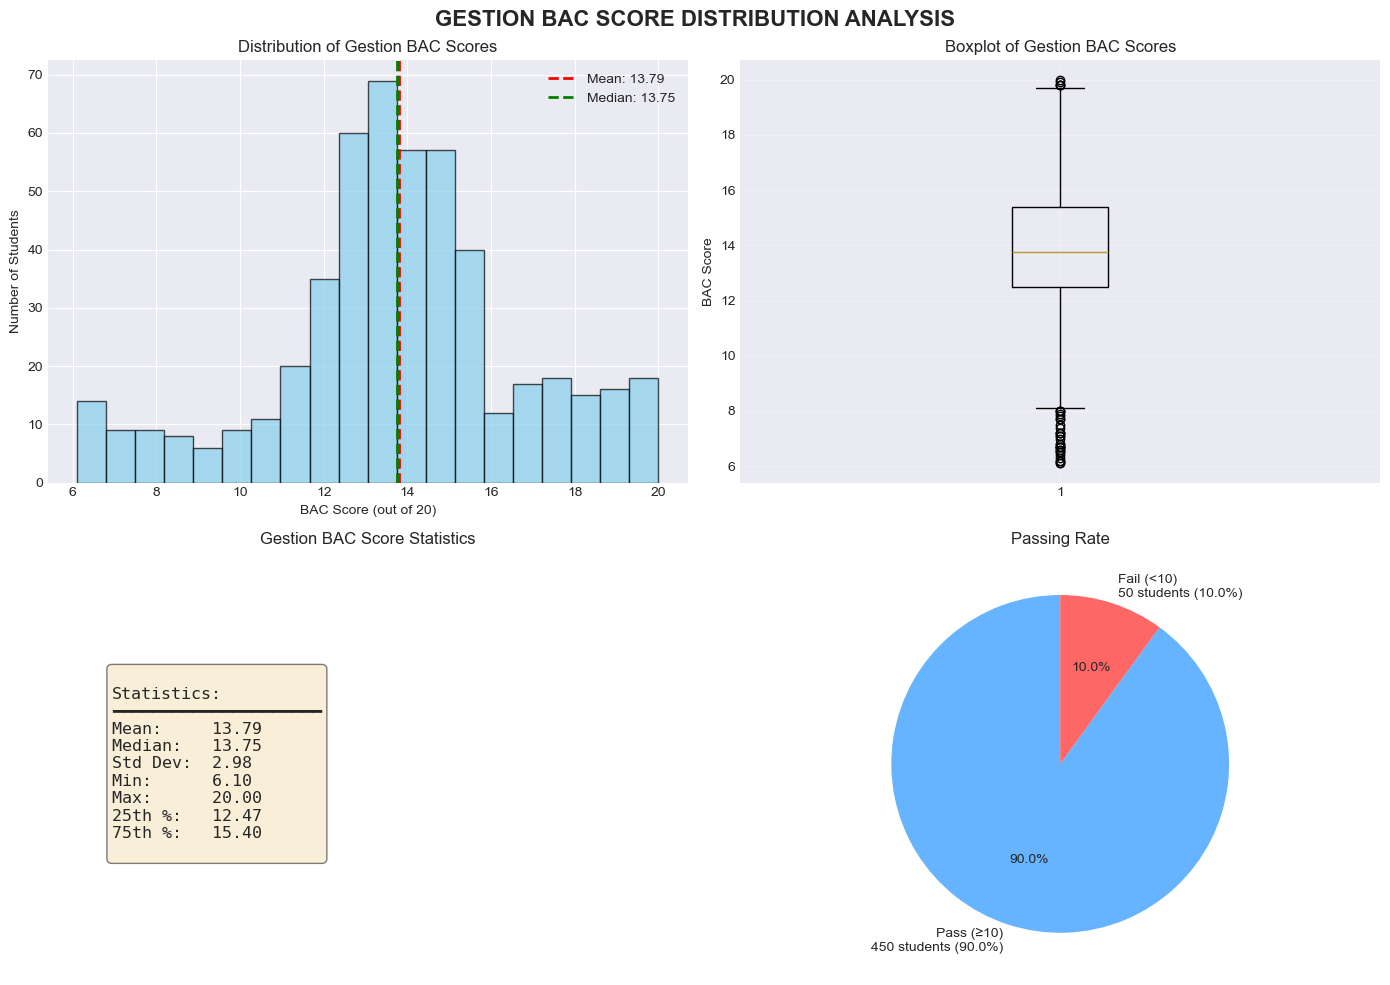


📊 GESTION BAC SCORE DISTRIBUTION SUMMARY
   Mean BAC Score:     13.79/20
   Median BAC Score:   13.75/20
   Standard Deviation: 2.98
   Pass Rate (≥10):    90.0% (450/500 students)
   Fail Rate (<10):    10.0% (50/500 students)

✅ Cell 6 complete! Ready for Cell 7


In [4]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of BAC scores
axes[0,0].hist(df['bac_score_gestion'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_gestion'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_gestion"].mean():.2f}')
axes[0,0].axvline(df['bac_score_gestion'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_gestion"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Gestion BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_gestion'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Gestion BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_gestion'].mean():.2f}
Median:   {df['bac_score_gestion'].median():.2f}
Std Dev:  {df['bac_score_gestion'].std():.2f}
Min:      {df['bac_score_gestion'].min():.2f}
Max:      {df['bac_score_gestion'].max():.2f}
25th %:   {df['bac_score_gestion'].quantile(0.25):.2f}
75th %:   {df['bac_score_gestion'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Gestion BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_gestion'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('GESTION BAC SCORE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📊 GESTION BAC SCORE DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"   Mean BAC Score:     {df['bac_score_gestion'].mean():.2f}/20")
print(f"   Median BAC Score:   {df['bac_score_gestion'].median():.2f}/20")
print(f"   Standard Deviation: {df['bac_score_gestion'].std():.2f}")
print(f"   Pass Rate (≥10):    {passing/len(df)*100:.1f}% ({passing}/{len(df)} students)")
print(f"   Fail Rate (<10):    {failing/len(df)*100:.1f}% ({failing}/{len(df)} students)")
print("=" * 60)

print("\n✅ Cell 6 complete! Ready for Cell 7")


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_gestion        : 1.000
   avg_grade                : 0.723
   grade_t3                 : 0.683
   grade_t2                 : 0.674
   grade_t1                 : 0.668
   calculation_accuracy     : 0.635
   financial_logic          : 0.617
   cost_block               : 0.578
   financial_block          : 0.555
   table_handling           : 0.531
   loan_block               : 0.517
   execution_speed          : 0.435
   bac_practiced            : 0.407
   weekly_exercises         : 0.380
   mock_exams               : 0.346
   study_hours              : 0.290
   consistency              : 0.268
   confidence               : 0.127
   gestion_imbalance        : 0.078
   grade_trend              : -0.030
   stress                   : -0.102


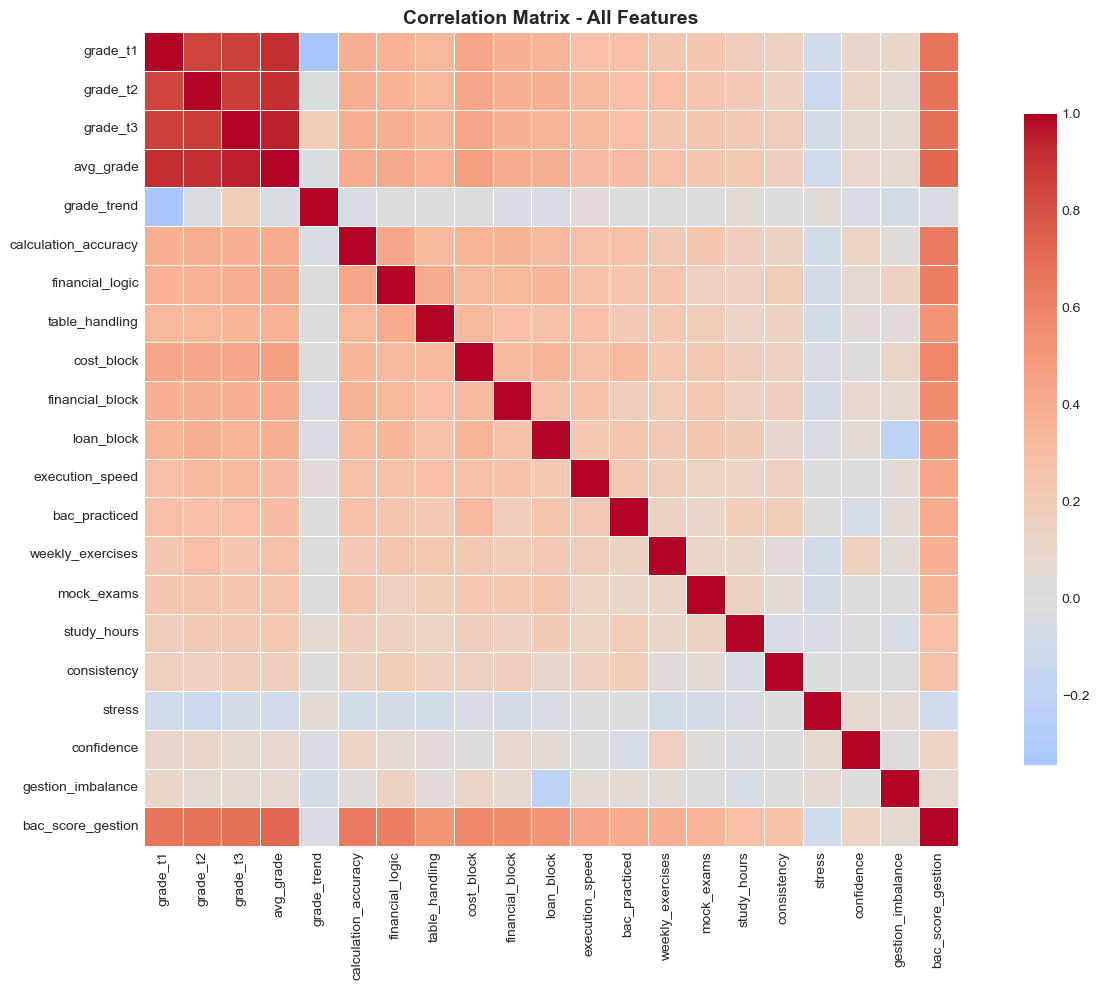

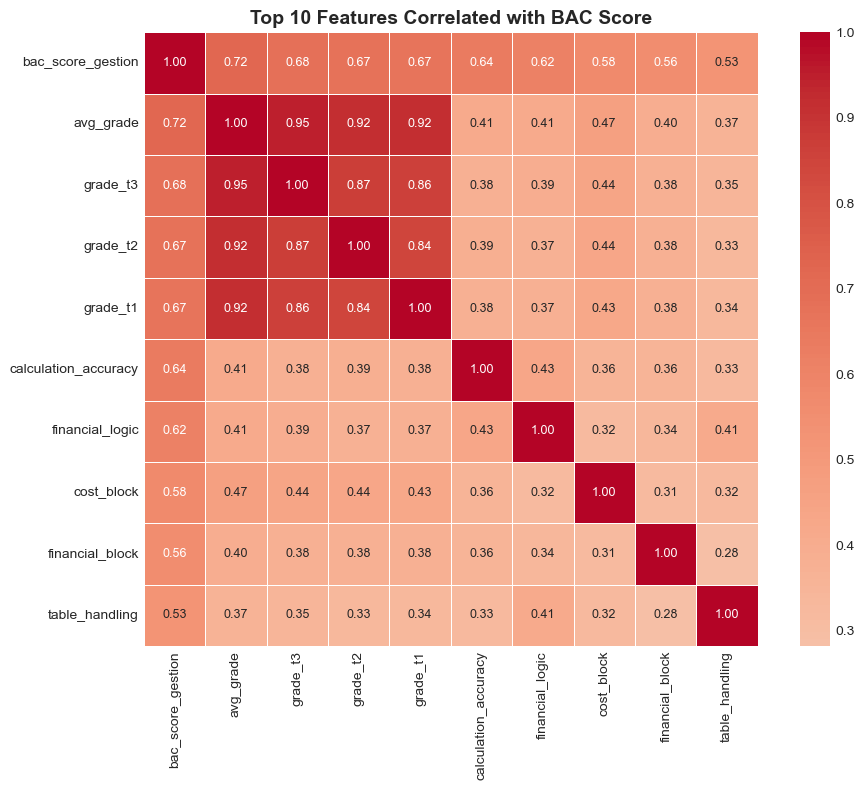


✅ Cell 7 complete! Ready for Cell 8


In [7]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation with target
corr_matrix = df.corr()
bac_corr = corr_matrix['bac_score_gestion'].sort_values(ascending=False)

print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 50)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:25s}: {corr_value:.3f}")

# Heatmap 1: All features
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap 2: Top features only
top_features = bac_corr.head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Top 10 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Cell 7 complete! Ready for Cell 8")

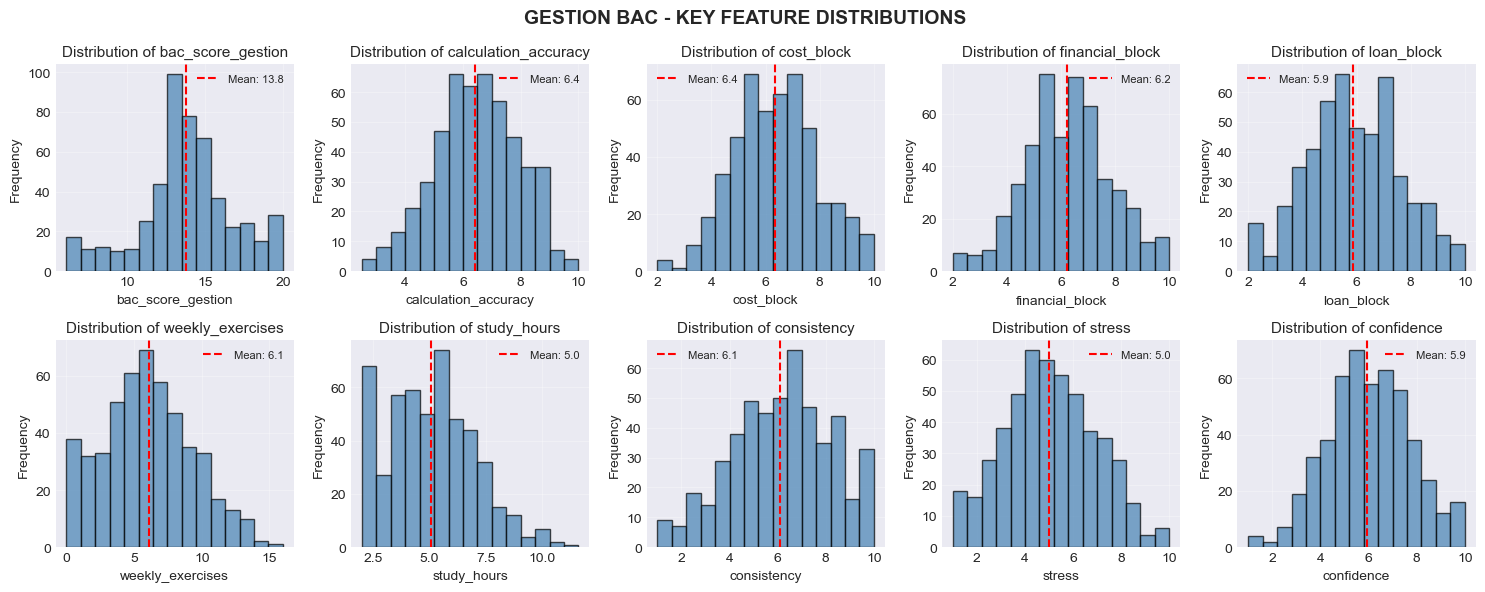


✅ Cell 8 complete! Ready for Cell 9


In [15]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS
# ============================================

import matplotlib.pyplot as plt

# Select key features
key_features = ['bac_score_gestion', 'calculation_accuracy', 'cost_block', 
                'financial_block', 'loan_block', 'weekly_exercises', 
                'study_hours', 'consistency', 'stress', 'confidence']

# Filter available features
available_features = [f for f in key_features if f in df.columns]

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GESTION BAC - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Cell 8 complete! Ready for Cell 9")

In [16]:
# ============================================
# CELL 9: FEATURE ENGINEERING - GESTION
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy
df_fe = df.copy()

# 1. Practice intensity (weighted average of practice features)
df_fe['practice_intensity'] = (
    df_fe['weekly_exercises'] / 20 * 10 * 0.5 +
    df_fe['bac_practiced'] / 30 * 10 * 0.3 +
    df_fe['mock_exams'] / 15 * 10 * 0.2
).round(1)

# 2. Study quality (consistency + study hours)
df_fe['study_quality'] = (
    df_fe['consistency'] * 0.6 + 
    df_fe['study_hours'] / 12 * 10 * 0.4
).round(1)

# 3. Overall gestion level (average of 3 main blocks)
df_fe['overall_level'] = (
    df_fe['cost_block'] + 
    df_fe['financial_block'] + 
    df_fe['loan_block']
).round(1)

print("\n✅ New features created:")
print("   • practice_intensity (0-10)")
print("   • study_quality (0-10)")
print("   • overall_level (0-10)")

# Update dataframe
df = df_fe.copy()

print(f"\n📊 Total columns now: {df.shape[1]}")
print("✅ Cell 9 complete! Ready for Cell 10")

FEATURE ENGINEERING

✅ New features created:
   • practice_intensity (0-10)
   • study_quality (0-10)
   • overall_level (0-10)

📊 Total columns now: 24
✅ Cell 9 complete! Ready for Cell 10


In [4]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# Define features (X) and target (y)
X = df.drop('bac_score_gestion', axis=1)
y = df['bac_score_gestion']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_gestion")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

print("\n✅ Cell 10 complete! Ready for Cell 11")

TRAIN/TEST SPLIT

📊 Features (X): 23 columns
📊 Target (y): bac_score_gestion

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

✅ Cell 10 complete! Ready for Cell 11


In [17]:
# ============================================
# CELL 11: MODEL TRAINING - GESTION BAC
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - GESTION BAC")
print("=" * 40)

# Train Random Forest
print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# Feature Importance
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")

print("\n✅ Cell 11 complete! Ready for Cell 12")

MODEL TRAINING - GESTION BAC

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  1.01 points
   RMSE: 1.27 points
   R²:   0.807

FEATURE IMPORTANCE

Top 10 most important features:
   overall_level            : 0.4409
   avg_grade                : 0.1336
   calculation_accuracy     : 0.0856
   financial_logic          : 0.0758
   grade_t3                 : 0.0397
   grade_t2                 : 0.0385
   table_handling           : 0.0297
   practice_intensity       : 0.0257
   grade_t1                 : 0.0214
   cost_block               : 0.0112

✅ Cell 11 complete! Ready for Cell 12


MODEL EVALUATION (DETAILED) - GESTION BAC

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     1.013 points
   Root Mean Squared Error (RMSE): 1.267 points
   R² Score:                      0.807

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.980 (98.0%)

   Confusion Matrix:
   True Negatives (correct fail):  5
   False Positives:                1
   False Negatives:                1
   True Positives (correct pass):  93


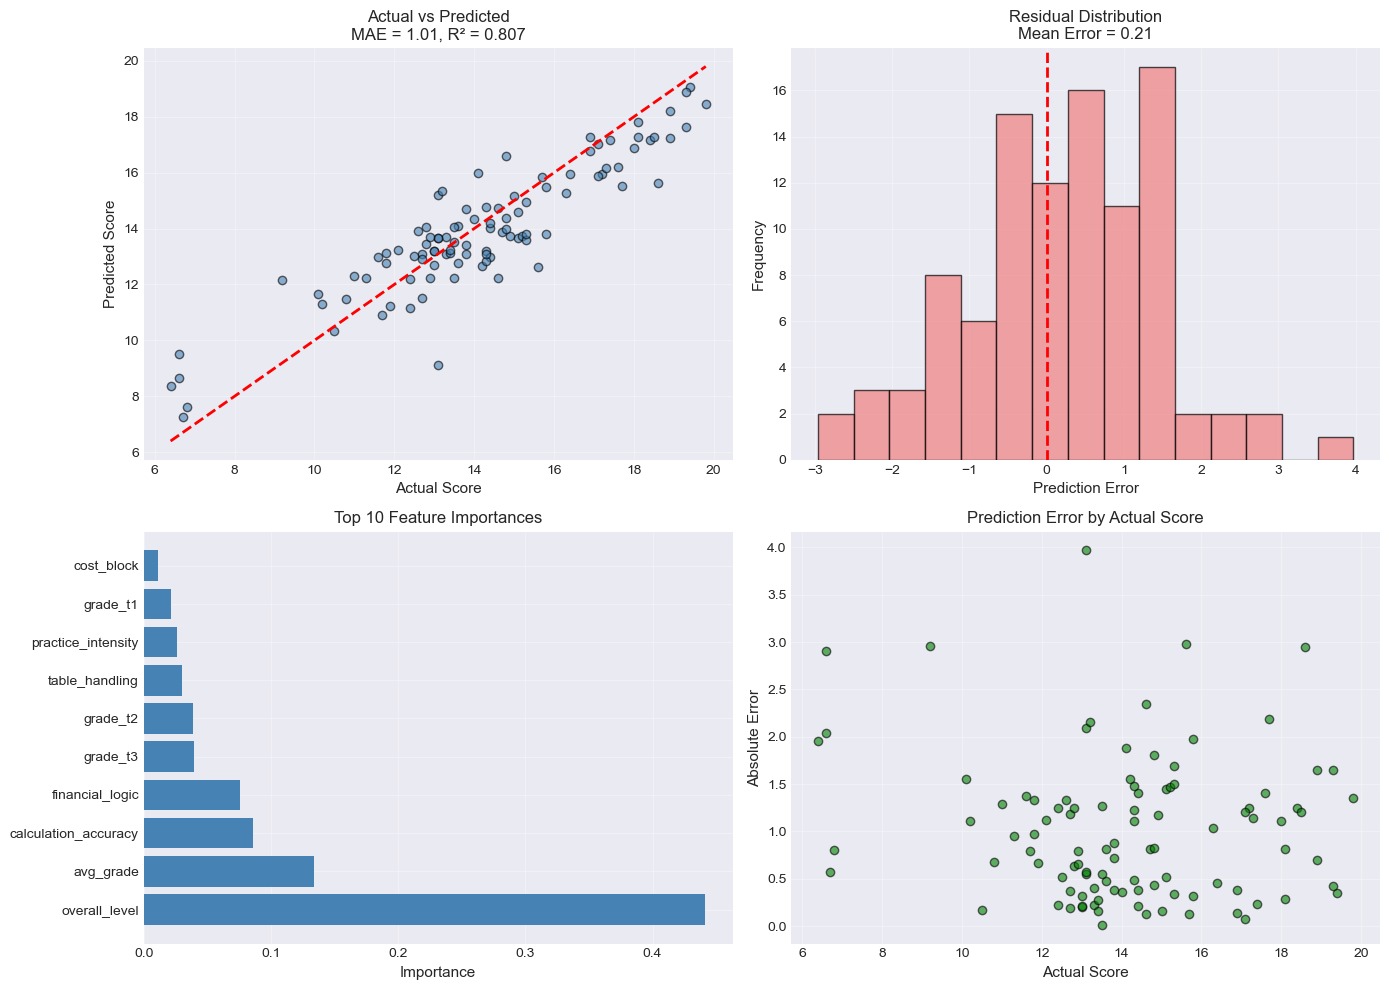


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      1.013 points
   Median Error:    0.824 points
   Error < 1 point: 54.0% of predictions
   Error < 2 points: 90.0% of predictions

✅ Evaluation Complete


In [18]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - GESTION BAC
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - GESTION BAC")
print("=" * 50)

# 1. Score Prediction Metrics
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# 2. Pass/Fail Classification
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0,0].set_xlabel('Actual Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted\nMAE = {mae:.2f}, R² = {r2:.3f}', fontsize=12)
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
top_features = feature_importance.head(10)
axes[1,0].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 10 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Error by Actual Score
axes[1,1].scatter(y_test, np.abs(residuals), alpha=0.6, color='green', edgecolors='black')
axes[1,1].set_xlabel('Actual Score', fontsize=11)
axes[1,1].set_ylabel('Absolute Error', fontsize=11)
axes[1,1].set_title('Prediction Error by Actual Score', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Error Summary
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - GESTION BAC

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 23)


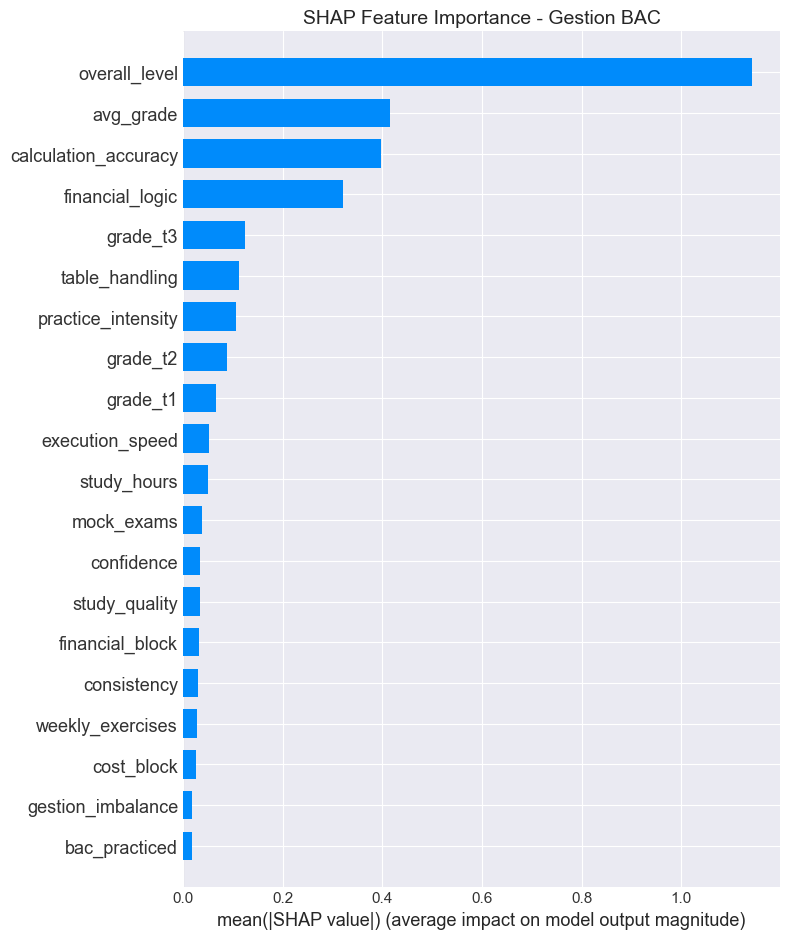

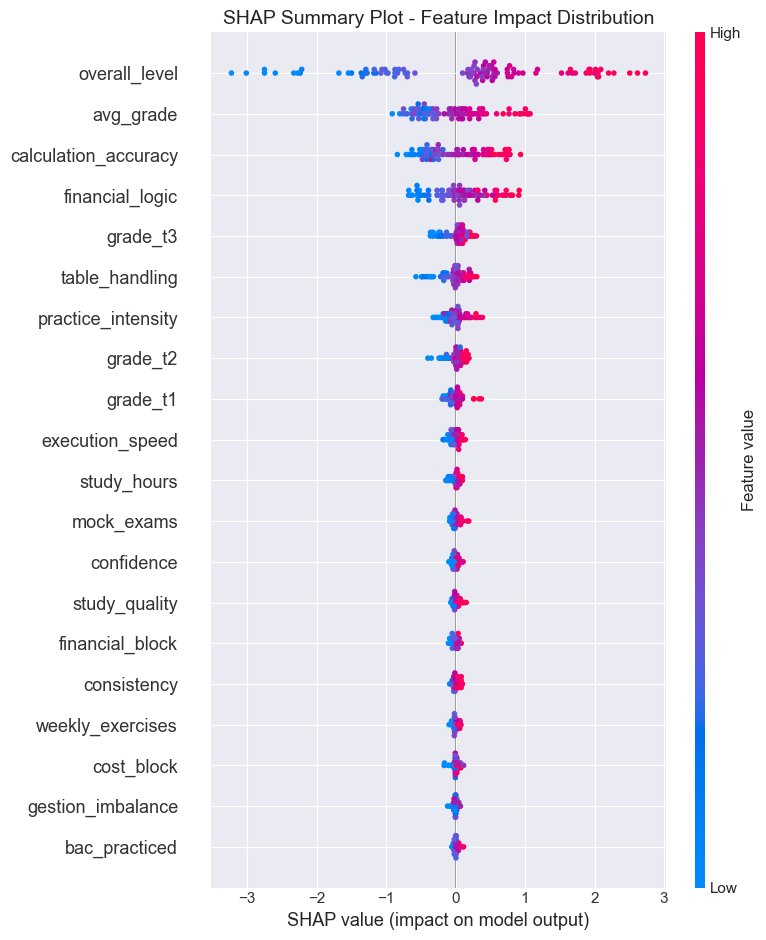


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual score: 12.7
   Predicted score: 13.1


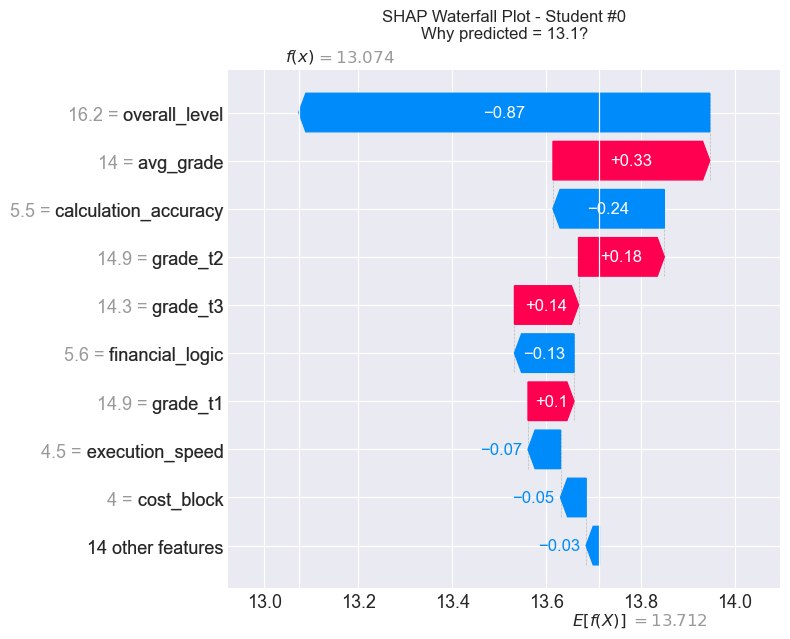


✅ SHAP Explainability Complete


In [19]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - GESTION BAC
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - GESTION BAC")
print("=" * 50)

# Create SHAP explainer
print("\n📊 Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# Visualization 1: Feature Importance (SHAP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Gestion BAC', fontsize=14)
plt.tight_layout()
plt.show()

# Visualization 2: Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Single student explanation
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual score: {student_actual:.1f}")
print(f"   Predicted score: {student_pred:.1f}")

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [20]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS - GESTION BAC (FIXED)
# ============================================

from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - GESTION BAC")
print("=" * 50)

# Get feature names and SHAP values
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Weaknesses (negative contributions)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Strengths (positive contributions)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    # Safely get weakness strings
    w1 = f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None"
    w2 = f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None"
    w3 = f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None"
    
    # Safely get strength strings
    s1 = f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None"
    s2 = f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None"
    s3 = f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None"
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': w1,
        'weakness_2': w2,
        'weakness_3': w3,
        'strength_1': s1,
        'strength_2': s2,
        'strength_3': s3,
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# Display first 10 students
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses: {row['weakness_1']} | {row['weakness_2']} | {row['weakness_3']}")
    print(f"   🟢 Strengths: {row['strength_1']} | {row['strength_2']} | {row['strength_3']}")

# Most common weaknesses
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 10 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(10):
    print(f"   • {feature}: {count} students")

# Recommendations
print("\n" + "=" * 50)
print("💡 RECOMMENDATIONS")
print("=" * 50)

recommendations = {
    'calculation_accuracy': '🧮 تدرب على الحسابات الدقيقة - راجع العمليات الحسابية',
    'cost_block': '📊 ركز على تسيير التكاليف - تدرب على جداول التوزيع',
    'financial_block': '💰 عزز مهاراتك في المحاسبة المالية - تسويات نهاية السنة',
    'loan_block': '🏦 تدرب على حسابات القروض والفائدة المركبة',
    'financial_logic': '🧠 طور المنطق المالي وحلل الحالات',
    'table_handling': '📋 تدرب على ملء الجداول بسرعة ودقة',
    'execution_speed': '⚡ حل تمارين بوقت محدد لزيادة السرعة',
    'weekly_exercises': '📚 زد عدد التمارين الأسبوعية إلى 10',
    'study_quality': '📖 نظم وقتك وذاكر يومياً بدلاً من المذاكرة المكثفة',
    'avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'study_hours': '⏰ خصص 4-5 ساعات أسبوعياً للمادة'
}

print("\n📋 Based on common weaknesses:")
for feature, count in weakness_counts.most_common(7):
    if feature in recommendations:
        print(f"   • {recommendations[feature]}")
    else:
        print(f"   • {feature}: ركز على تحسين هذا المجال")

# Save
weakness_df.to_csv('weakness_analysis_gestion.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_gestion.csv'")
print("=" * 50)

WEAKNESS ANALYSIS - GESTION BAC

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=12.7, Predicted=13.1
   🔴 Weaknesses: overall_level (-0.87) | calculation_accuracy (-0.24) | financial_logic (-0.13)
   🟢 Strengths: avg_grade (+0.33) | grade_t2 (+0.18) | grade_t3 (+0.14)

🔹 STUDENT 2: Actual=18.6, Predicted=15.6
   🔴 Weaknesses: practice_intensity (-0.08) | execution_speed (-0.07) | gestion_imbalance (-0.04)
   🟢 Strengths: overall_level (+0.81) | calculation_accuracy (+0.67) | avg_grade (+0.22)

🔹 STUDENT 3: Actual=15.1, Predicted=13.7
   🔴 Weaknesses: calculation_accuracy (-0.51) | grade_trend (-0.11) | study_hours (-0.08)
   🟢 Strengths: overall_level (+0.31) | financial_logic (+0.13) | grade_t3 (+0.10)

🔹 STUDENT 4: Actual=16.9, Predicted=17.3
   🔴 Weaknesses: practice_intensity (-0.14) | gestion_imbalance (-0.12) | consistency (-0.02)
   🟢 Strengths: overall_level (+2.04) | financial_logic (+0.79) | calculation_accuracy 

SIMULATION ENGINE - GESTION BAC
How improving skills affects your score

👤 Average student profile:
   Current score: 13.8/20
   Calculation accuracy: 5.2/10
   Cost block: 7.6/10
   Financial block: 5.9/10
   Loan block: 7.2/10

📈 SIMULATION RESULTS:
-------------------------------------------------------

⚪ 📊 تحسين تسيير التكاليف +2:
   13.8 → 14.0 (+0.20)

⚪ 💰 تحسين المحاسبة المالية +2:
   13.8 → 14.0 (+0.20)

⚪ 🏦 تحسين قروض الاستثمار +2:
   13.8 → 14.0 (+0.18)

⚪ 🧮 تحسين دقة الحسابات +2:
   13.8 → 14.0 (+0.24)

⚪ 📋 حل 5 تمارين إضافية أسبوعياً:
   13.8 → 13.8 (+0.04)

⚪ ⚡ تحسين سرعة التنفيذ +2:
   13.8 → 13.9 (+0.12)

⚪ 🎯 تحسين المنطق المالي +2:
   13.8 → 14.0 (+0.16)

🟢 ✨ تحسين كل المهارات (+2 لكل فرع):
   13.8 → 14.7 (+0.94)

🎯 BEST RECOMMENDATION

✅ 🧮 تحسين دقة الحسابات +2
   → Expected improvement: +0.24 points


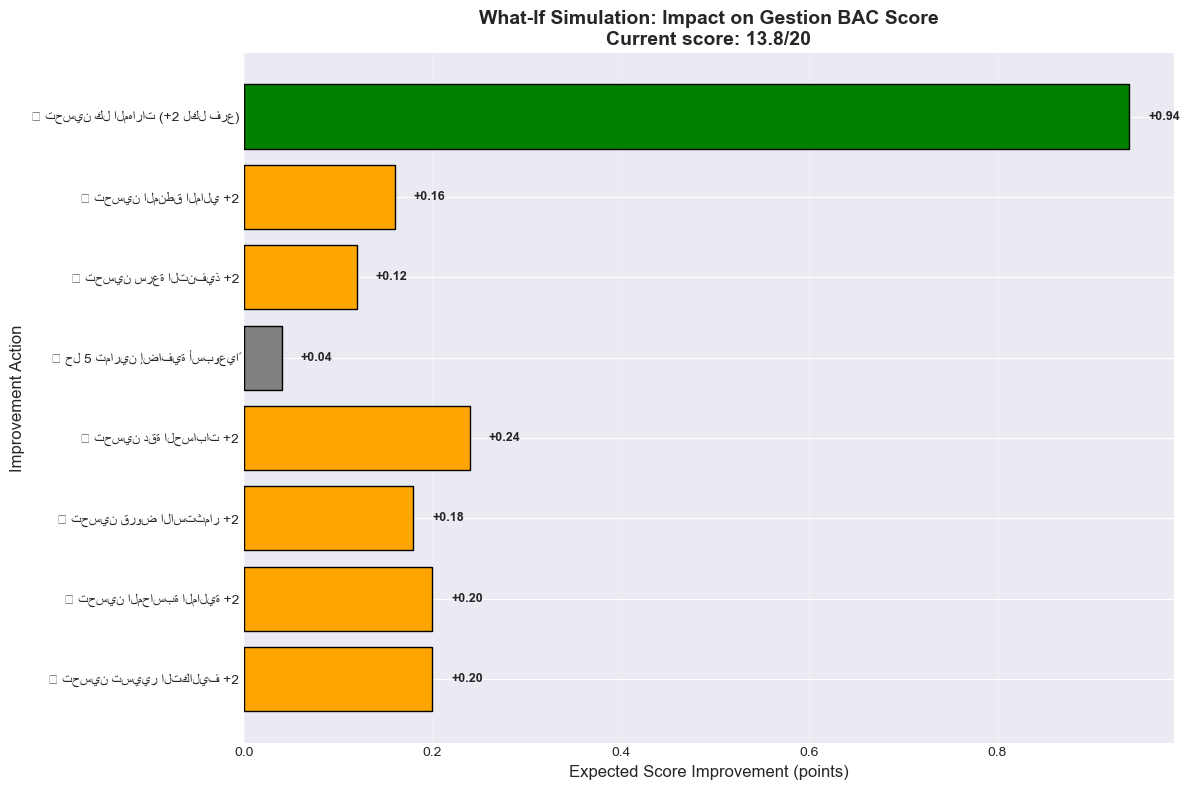


📊 IMPACT TABLE
                      Skill Expected Gain
      تحسين دقة الحسابات +2     +0.24 pts
    تحسين تسيير التكاليف +2     +0.20 pts
  تحسين المحاسبة المالية +2     +0.20 pts
    تحسين قروض الاستثمار +2     +0.18 pts
حل 5 تمارين إضافية أسبوعياً     +0.04 pts
      تحسين سرعة التنفيذ +2     +0.12 pts

💡 TIPS:
   • دقة الحسابات والتكاليف هما الأكثر تأثيراً على نقطتك
   • حل التمارين أسبوعياً يرفع نقطتك بشكل ملحوظ
   • العوامل النفسية تأثيرها ضئيل - طلاب التسيير هادئون!

✅ Simulation Engine Complete


In [21]:
# ============================================
# CELL 15: SIMULATION ENGINE - GESTION BAC
# ============================================

import matplotlib.pyplot as plt

print("=" * 60)
print("SIMULATION ENGINE - GESTION BAC")
print("How improving skills affects your score")
print("=" * 60)

# Impact factors (based on correlations from your data)
impact_factors = {
    'calculation_accuracy': 0.12,
    'cost_block': 0.10,
    'financial_block': 0.10,
    'loan_block': 0.09,
    'financial_logic': 0.08,
    'table_handling': 0.07,
    'execution_speed': 0.06,
    'weekly_exercises': 0.04,  # per +5 exercises
    'study_quality': 0.03
}

# Find average student
avg_bac = df['bac_score_gestion'].mean()
target_student = df.iloc[(df['bac_score_gestion'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Average student profile:")
print(f"   Current score: {target_student['bac_score_gestion']:.1f}/20")
print(f"   Calculation accuracy: {target_student.get('calculation_accuracy', 5):.1f}/10")
print(f"   Cost block: {target_student.get('cost_block', 5):.1f}/10")
print(f"   Financial block: {target_student.get('financial_block', 5):.1f}/10")
print(f"   Loan block: {target_student.get('loan_block', 5):.1f}/10")

# Simulation function
def simulate_improvement(student, improvements):
    original = student['bac_score_gestion']
    gain = 0
    
    for skill, delta in improvements.items():
        if skill in impact_factors:
            if skill == 'weekly_exercises':
                gain += (delta / 5) * impact_factors[skill]
            else:
                gain += delta * impact_factors[skill]
    
    new_score = min(original + gain, 20)
    new_score = max(new_score, 0)
    return {'original': original, 'new': new_score, 'gain': gain}

# Scenarios
scenarios = [
    ("📊 تحسين تسيير التكاليف +2", {"cost_block": 2}),
    ("💰 تحسين المحاسبة المالية +2", {"financial_block": 2}),
    ("🏦 تحسين قروض الاستثمار +2", {"loan_block": 2}),
    ("🧮 تحسين دقة الحسابات +2", {"calculation_accuracy": 2}),
    ("📋 حل 5 تمارين إضافية أسبوعياً", {"weekly_exercises": 5}),
    ("⚡ تحسين سرعة التنفيذ +2", {"execution_speed": 2}),
    ("🎯 تحسين المنطق المالي +2", {"financial_logic": 2}),
    ("✨ تحسين كل المهارات (+2 لكل فرع)", {
        "calculation_accuracy": 2, "cost_block": 2, 
        "financial_block": 2, "loan_block": 2, "execution_speed": 2
    })
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 55)

results = []
for name, changes in scenarios:
    result = simulate_improvement(target_student, changes)
    results.append(result)
    
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {name}:")
    print(f"   {result['original']:.1f} → {result['new']:.1f} (+{result['gain']:.2f})")

# Best recommendation
best_idx = max(range(len(results)-1), key=lambda i: results[i]['gain'])
best_scenario = scenarios[best_idx]
best_gain = results[best_idx]['gain']

print("\n" + "=" * 60)
print("🎯 BEST RECOMMENDATION")
print("=" * 60)
print(f"\n✅ {best_scenario[0]}")
print(f"   → Expected improvement: +{best_gain:.2f} points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

scenario_names = [s[0][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Gestion BAC Score\nCurrent score: {target_student["bac_score_gestion"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print("📊 IMPACT TABLE")
print("=" * 60)

impact_table = pd.DataFrame({
    'Skill': [
        'تحسين دقة الحسابات +2',
        'تحسين تسيير التكاليف +2',
        'تحسين المحاسبة المالية +2',
        'تحسين قروض الاستثمار +2',
        'حل 5 تمارين إضافية أسبوعياً',
        'تحسين سرعة التنفيذ +2'
    ],
    'Expected Gain': [
        f'+{impact_factors["calculation_accuracy"]*2:.2f} pts',
        f'+{impact_factors["cost_block"]*2:.2f} pts',
        f'+{impact_factors["financial_block"]*2:.2f} pts',
        f'+{impact_factors["loan_block"]*2:.2f} pts',
        f'+{impact_factors["weekly_exercises"]:.2f} pts',
        f'+{impact_factors["execution_speed"]*2:.2f} pts'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 TIPS:")
print("   • دقة الحسابات والتكاليف هما الأكثر تأثيراً على نقطتك")
print("   • حل التمارين أسبوعياً يرفع نقطتك بشكل ملحوظ")
print("   • العوامل النفسية تأثيرها ضئيل - طلاب التسيير هادئون!")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [22]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - GESTION
# ============================================

print("=" * 60)
print("📖 فهم نتائجك في التسيير المحاسبي والمالي")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# Sample student
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_gestion']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# Core Skills
print("\n📚 المهارات الأساسية:")
print("-" * 60)

core_skills = [
    ('calculation_accuracy', '🧮 دقة الحسابات', 'تدرب على العمليات الحسابية بدقة'),
    ('financial_logic', '🧠 المنطق المالي', 'حلل الحالات المالية منطقياً'),
    ('table_handling', '📋 التعامل مع الجداول', 'تدرب على ملء الجداول المالية')
]

for skill, name, advice in core_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# BAC Blocks
print("\n" + "=" * 60)
print("📊 أجزاء امتحان البكالوريا")
print("=" * 60)

blocks = [
    ('cost_block', '📊 تسيير التكاليف (6 نقاط)', 'ركز على جداول التوزيع وحساب التكاليف'),
    ('financial_block', '💰 المحاسبة المالية (8 نقاط)', 'تدرب على تسويات نهاية السنة والاهتلاكات'),
    ('loan_block', '🏦 قروض الاستثمار (6 نقاط)', 'راجع حسابات الفائدة المركبة وجدول الاستهلاك')
]

for block, name, advice in blocks:
    if block in df.columns:
        value = sample_student[block]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# Study Habits
print("\n" + "=" * 60)
print("📖 عادات الدراسة")
print("=" * 60)

habits = [
    ('weekly_exercises', '📋 تمارين أسبوعياً', 20),
    ('bac_practiced', '📚 امتحانات بكالوريا محلولة', 30),
    ('study_hours', '⏰ ساعات الدراسة الأسبوعية', 12),
    ('consistency', '📅 الانتظام في الدراسة', 10)
]

for habit, name, max_val in habits:
    if habit in df.columns:
        value = sample_student[habit]
        percentage = (value / max_val) * 100
        
        if percentage >= 70:
            level = "🟢 ممتاز"
        elif percentage >= 50:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.0f}/{max_val}")
        print(f"   → مستواك: {level} ({percentage:.0f}%)")
        
        if habit == 'weekly_exercises' and value < 10:
            print(f"   💡 نصيحة: حاول حل {10 - value:.0f} تمرين إضافي أسبوعياً")
        elif habit == 'bac_practiced' and value < 10:
            print(f"   💡 نصيحة: حل 10 امتحانات بكالوريا على الأقل")
        elif habit == 'study_hours' and value < 4:
            print(f"   💡 نصيحة: خصص 4-5 ساعات أسبوعياً للمادة")

# Exam Factors (Low impact)
print("\n" + "=" * 60)
print("🧠 العوامل النفسية (تأثيرها ضئيل)")
print("=" * 60)

print(f"\n😰 مستوى التوتر: {sample_student['stress']:.1f}/10")
print(f"💪 الثقة: {sample_student['confidence']:.1f}/10")
print("   💡 نصيحة: طلاب التسيير هادئون - لا تقلق كثيراً!")

# Overall level
print("\n" + "=" * 60)
print("🎯 مستواك العام")
print("=" * 60)

overall = (sample_student['cost_block'] + sample_student['financial_block'] + sample_student['loan_block']) / 3
if overall >= 7:
    print(f"   ✅ مستواك العام: {overall:.1f}/10 - ممتاز!")
elif overall >= 5:
    print(f"   📈 مستواك العام: {overall:.1f}/10 - جيد، يمكن تحسينه")
else:
    print(f"   ⚠️ مستواك العام: {overall:.1f}/10 - يحتاج إلى عمل")

# Recommendations
print("\n" + "=" * 60)
print("📋 توصيات مخصصة")
print("=" * 60)

recommendations_list = []

if sample_student['calculation_accuracy'] < 6:
    recommendations_list.append("• 🧮 تدرب على الحسابات الدقيقة - راجع العمليات الحسابية")
if sample_student['cost_block'] < 6:
    recommendations_list.append("• 📊 ركز على تسيير التكاليف - تدرب على جداول التوزيع")
if sample_student['financial_block'] < 6:
    recommendations_list.append("• 💰 عزز مهاراتك في المحاسبة المالية - تسويات نهاية السنة")
if sample_student['loan_block'] < 6:
    recommendations_list.append("• 🏦 تدرب على حسابات القروض والفائدة المركبة")
if sample_student['weekly_exercises'] < 10:
    recommendations_list.append("• 📋 حل 10 تمارين أسبوعياً لتحسين سرعتك")

if recommendations_list:
    for rec in recommendations_list[:5]:
        print(f"   {rec}")
else:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: دقة الحسابات وتسيير التكاليف هما مفتاح النجاح")
print(f"   نقطتك الحالية: {sample_student['bac_score_gestion']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في التسيير المحاسبي والمالي
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 8.4/20
   معدل الفصول الثلاثة: 8.0/20

------------------------------------------------------------

📚 المهارات الأساسية:
------------------------------------------------------------

🧮 دقة الحسابات: 7.8/10
   → مستواك: 🟢 قوي
   💡 نصيحة: تدرب على العمليات الحسابية بدقة

🧠 المنطق المالي: 4.9/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: حلل الحالات المالية منطقياً

📋 التعامل مع الجداول: 5.8/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على ملء الجداول المالية

📊 أجزاء امتحان البكالوريا

📊 تسيير التكاليف (6 نقاط): 6.9/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: ركز على جداول التوزيع وحساب التكاليف

💰 المحاسبة المالية (8 نقاط): 5.2/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تدرب على تسويات نهاية السنة والاهتلاكات

🏦 قروض الاستثمار (6 نقاط): 6.5/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: راجع حسابات الفائدة المركبة وجدول الاستهلاك

📖 عادات الدراسة

📋 تمارين أسبوعياً: 2/20
   → مستواك: 🔴 يحتاج إ

In [12]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("📊 منصة تحسين الأداء في التسيير المحاسبي والمالي - البكالوريا الجزائرية (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📊 امتحان البكالوريا - التسيير المحاسبي والمالي</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعبة: تسيير واقتصاد</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 4 ساعات | المجموع: 20 نقطة</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">4 ساعات</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">أجزاء الامتحان</div>
            <div style="font-size: 14px;">3 أجزاء</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في التسيير المحاسبي والمالي</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 أجزاء الامتحان</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">الجزء</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
             </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الأول</strong></td>
                <td style="padding: 10px;">تسيير التكاليف (جداول التوزيع، كلفة الشراء، كلفة الإنتاج)</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثاني</strong></td>
                <td style="padding: 10px;">المحاسبة المالية (تسويات نهاية السنة، الاهتلاكات، الميزانية)</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
             </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثالث</strong></td>
                <td style="padding: 10px;">قروض الاستثمار (الفائدة المركبة، جدول الاستهلاك، اختيار المشاريع)</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
             </tr>
        </table>
    </div>
"""

# Importance by topic
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>دقة الحسابات</strong></div>
                <div style="font-size: 12px; color: #666;">الأهم! (0.65)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>تسيير التكاليف</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير كبير (0.55)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>المحاسبة المالية</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير كبير (0.55)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>قروض الاستثمار</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير متوسط (0.50)</div>
            </div>
        </div>
    </div>
"""

# Critical note
note_html = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📋 ملاحظة مهمة</h3>
        <p style="line-height: 1.6;">
            • <strong>دقة الحسابات</strong> هي المهارة الأكثر أهمية - خطأ بسيط يكلفك نقاطاً كثيرة<br>
            • <strong>تسيير التكاليف</strong> يعتمد على جداول التوزيع - تدرب على ملئها بسرعة<br>
            • <strong>المحاسبة المالية</strong> تمثل 8 نقاط - ركز على تسويات نهاية السنة<br>
            • <strong>حل التمارين أسبوعياً</strong> يرفع نقطتك بشكل ملحوظ<br>
            • <strong>العوامل النفسية</strong> لها تأثير ضئيل (طلاب التسيير هادئون!)
        </p>
    </div>
"""

# How it works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - درجاتك ومستويات مهاراتك</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد المجالات التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + note_html + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا (شعبة تسيير واقتصاد) على تحسين أدائهم</p>
        <p style="color: #888; font-size: 12px;">📊 تذكر: دقة الحسابات والتكاليف هما مفتاح النجاح 📊</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

📊 منصة تحسين الأداء في التسيير المحاسبي والمالي - البكالوريا الجزائرية (شعبة تسيير واقتصاد)


الجزء,المحتوى,النقاط
الجزء الأول,تسيير التكاليف (جداول التوزيع، كلفة الشراء، كلفة الإنتاج),6 نقاط
الجزء الثاني,المحاسبة المالية (تسويات نهاية السنة، الاهتلاكات، الميزانية),8 نقاط
الجزء الثالث,قروض الاستثمار (الفائدة المركبة، جدول الاستهلاك، اختيار المشاريع),6 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [23]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - GESTION
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - التسيير المحاسبي والمالي (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 1. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 2: Core Skills
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎯 2. المهارات الأساسية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0=ضعيف، 10=ممتاز)</p>
</div>
"""
display(HTML(skills_html))

skill_style = widgets.Layout(width='100%', padding='5px')

calculation_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                          description='🧮 دقة الحسابات (الأهم!):', 
                                          style={'description_width': '250px'}, layout=skill_style)
financial_logic_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                              description='🧠 المنطق المالي:', 
                                              style={'description_width': '250px'}, layout=skill_style)
table_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📋 التعامل مع الجداول:', 
                                    style={'description_width': '250px'}, layout=skill_style)

display(calculation_slider, financial_logic_slider, table_slider)

# ============================================
# SECTION 3: BAC Blocks
# ============================================

blocks_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. مستواك في أجزاء البكالوريا</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(blocks_html))

cost_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='📊 تسيير التكاليف (6 نقاط):', 
                                   style={'description_width': '250px'}, layout=skill_style)
financial_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='💰 المحاسبة المالية (8 نقاط):', 
                                        style={'description_width': '250px'}, layout=skill_style)
loan_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                   description='🏦 قروض الاستثمار (6 نقاط):', 
                                   style={'description_width': '250px'}, layout=skill_style)

display(cost_slider, financial_slider, loan_slider)

# ============================================
# SECTION 4: Execution Skills
# ============================================

execution_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">⚡ 4. سرعة التنفيذ</h3>
    <p style="color: #666; font-size: 14px;">قيم سرعتك في حل التمارين من 0 إلى 10</p>
</div>
"""
display(HTML(execution_html))

execution_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='⚡ سرعة التنفيذ:', 
                                        style={'description_width': '250px'}, layout=skill_style)
display(execution_slider)

# ============================================
# SECTION 5: Practice
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #1abc9c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 5. عادات الدراسة والتمرين</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية</p>
</div>
"""
display(HTML(practice_html))

practice_style = widgets.Layout(width='100%', padding='5px')

weekly_slider = widgets.IntSlider(value=5, min=0, max=20, step=1, 
                                   description='📋 عدد التمارين أسبوعياً:', 
                                   style={'description_width': '250px'}, layout=practice_style)
bac_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, 
                                description='📚 عدد امتحانات البكالوريا المحلولة:', 
                                style={'description_width': '250px'}, layout=practice_style)
mock_slider = widgets.IntSlider(value=2, min=0, max=15, step=1, 
                                 description='📝 عدد الامتحانات التجريبية:', 
                                 style={'description_width': '250px'}, layout=practice_style)

display(weekly_slider, bac_slider, mock_slider)

# ============================================
# SECTION 6: Study Behavior
# ============================================

study_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 6. سلوك الدراسة</h3>
</div>
"""
display(HTML(study_html))

hours_slider = widgets.FloatSlider(value=5, min=2, max=12, step=0.5, 
                                    description='⏰ ساعات الدراسة الأسبوعية:', 
                                    style={'description_width': '250px'}, layout=skill_style)
consistency_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                          description='📅 الانتظام في الدراسة (1-10):', 
                                          style={'description_width': '250px'}, layout=skill_style)

display(hours_slider, consistency_slider)

# ============================================
# SECTION 7: Exam Factors (LOW impact)
# ============================================

exam_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 7. العوامل النفسية (تأثيرها ضئيل)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10</p>
</div>
"""
display(HTML(exam_html))

stress_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                     description='😰 مستوى التوتر:', 
                                     style={'description_width': '250px'}, layout=skill_style)
confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                         description='💪 الثقة في النفس:', 
                                         style={'description_width': '250px'}, layout=skill_style)

display(stress_slider, confidence_slider)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)
submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect inputs
def collect_inputs(b):
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(calculation_slider, financial_logic_slider, table_slider)
    display(HTML(blocks_html))
    display(cost_slider, financial_slider, loan_slider)
    display(HTML(execution_html))
    display(execution_slider)
    display(HTML(practice_html))
    display(weekly_slider, bac_slider, mock_slider)
    display(HTML(study_html))
    display(hours_slider, consistency_slider)
    display(HTML(exam_html))
    display(stress_slider, confidence_slider)
    display(submit_button)
    
    # Collect values
    user_input = {
        'grade_t1': grade_slider1.value,
        'grade_t2': grade_slider2.value,
        'grade_t3': grade_slider3.value,
        'avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'calculation_accuracy': calculation_slider.value,
        'financial_logic': financial_logic_slider.value,
        'table_handling': table_slider.value,
        'cost_block': cost_slider.value,
        'financial_block': financial_slider.value,
        'loan_block': loan_slider.value,
        'execution_speed': execution_slider.value,
        'weekly_exercises': weekly_slider.value,
        'bac_practiced': bac_slider.value,
        'mock_exams': mock_slider.value,
        'study_hours': hours_slider.value,
        'consistency': consistency_slider.value,
        'stress': stress_slider.value,
        'confidence': confidence_slider.value
    }
    
    # Store in global variable
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   دقة الحسابات: {calculation_slider.value}/10 (الأهم!)")
    print(f"   تسيير التكاليف: {cost_slider.value}/10")
    print(f"   المحاسبة المالية: {financial_slider.value}/10")
    print(f"   عدد التمارين أسبوعياً: {weekly_slider.value}/20")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

submit_button.on_click(collect_inputs)
display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")
print("💡 تذكر: دقة الحسابات هي المهارة الأكثر أهمية!")

📝 إدخال بيانات الطالب - التسيير المحاسبي والمالي (شعبة تسيير واقتصاد)


FloatSlider(value=6.0, description='🧮 دقة الحسابات (الأهم!):', layout=Layout(padding='5px', width='100%'), max…

FloatSlider(value=6.0, description='🧠 المنطق المالي:', layout=Layout(padding='5px', width='100%'), max=10.0, s…

FloatSlider(value=6.0, description='📋 التعامل مع الجداول:', layout=Layout(padding='5px', width='100%'), max=10…

FloatSlider(value=6.0, description='📊 تسيير التكاليف (6 نقاط):', layout=Layout(padding='5px', width='100%'), m…

...

FloatSlider(value=5.0, description='😰 مستوى التوتر:', layout=Layout(padding='5px', width='100%'), max=10.0, mi…

FloatSlider(value=6.0, description='💪 الثقة في النفس:', layout=Layout(padding='5px', width='100%'), max=10.0, …


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا', icon='check', layout=Layout(margin='…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق
💡 تذكر: دقة الحسابات هي المهارة الأكثر أهمية!


In [24]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features
    input_df = pd.DataFrame([user_input_data])
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['practice_intensity'] = (input_df['weekly_exercises'] / 20 * 10 * 0.5 +
                                       input_df['bac_practiced'] / 30 * 10 * 0.3 +
                                       input_df['mock_exams'] / 15 * 10 * 0.2).round(1)
    input_df['study_quality'] = (input_df['consistency'] * 0.6 + 
                                  input_df['study_hours'] / 12 * 10 * 0.4).round(1)
    input_df['overall_level'] = (input_df['cost_block'] + 
                                  input_df['financial_block'] + 
                                  input_df['loan_block']) / 3
    
    # Get model features
    model_features = X_train.columns.tolist()
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    X_input = input_df[model_features]
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    improvement_potential = max(0.5, min((19 - predicted_score) * 0.4, 6))
    
    # Determine level
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    prob_color = "#2ecc71" if success_prob >= 80 else "#f39c12" if success_prob >= 60 else "#e74c3c"
    
    # HTML Output
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - التسيير المحاسبي والمالي</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>🧮 دقة الحسابات: <strong>{user_input_data['calculation_accuracy']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['calculation_accuracy']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>📊 تسيير التكاليف: <strong>{user_input_data['cost_block']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['cost_block']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>💰 المحاسبة المالية: <strong>{user_input_data['financial_block']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['financial_block']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
                    <div>🏦 قروض الاستثمار: <strong>{user_input_data['loan_block']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['loan_block']*10}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📋 تمارين أسبوعياً: <strong>{user_input_data['weekly_exercises']:.0f}/20</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['weekly_exercises']/20*100}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>😰 مستوى التوتر: <strong>{user_input_data['stress']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['stress']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📊 ملاحظة مهمة</h3>
            <p style="line-height: 1.6;">
                • <strong>دقة الحسابات</strong> هي المهارة الأكثر أهمية - خطأ بسيط يكلفك نقاطاً كثيرة<br>
                • <strong>تسيير التكاليف</strong> يعتمد على جداول التوزيع - تدرب على ملئها بسرعة<br>
                • <strong>المحاسبة المالية</strong> تمثل 8 نقاط - ركز على تسويات نهاية السنة<br>
                • <strong>حل التمارين أسبوعياً</strong> يرفع نقطتك بشكل ملحوظ
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [21]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Target levels for each skill
    skill_targets = {
        'calculation_accuracy': 7.5,
        'cost_block': 7.0,
        'financial_block': 7.0,
        'loan_block': 6.5,
        'financial_logic': 6.5,
        'table_handling': 6.5,
        'execution_speed': 6.0
    }
    
    # Get user's skill values
    user_skills = {
        'calculation_accuracy': user_input_data.get('calculation_accuracy', 5),
        'cost_block': user_input_data.get('cost_block', 5),
        'financial_block': user_input_data.get('financial_block', 5),
        'loan_block': user_input_data.get('loan_block', 5),
        'financial_logic': user_input_data.get('financial_logic', 5),
        'table_handling': user_input_data.get('table_handling', 5),
        'execution_speed': user_input_data.get('execution_speed', 5)
    }
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'weekly_exercises': 12,
        'bac_practiced': 10,
        'study_hours': 5,
        'consistency': 7,
        'stress': 4,
        'confidence': 7
    }
    
    user_habits = {
        'weekly_exercises': user_input_data.get('weekly_exercises', 5),
        'bac_practiced': user_input_data.get('bac_practiced', 5),
        'study_hours': user_input_data.get('study_hours', 5),
        'consistency': user_input_data.get('consistency', 5),
        'stress': user_input_data.get('stress', 5),
        'confidence': user_input_data.get('confidence', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'stress':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Arabic names
    skill_names_ar = {
        'calculation_accuracy': '🧮 دقة الحسابات',
        'cost_block': '📊 تسيير التكاليف',
        'financial_block': '💰 المحاسبة المالية',
        'loan_block': '🏦 قروض الاستثمار',
        'financial_logic': '🧠 المنطق المالي',
        'table_handling': '📋 التعامل مع الجداول',
        'execution_speed': '⚡ سرعة التنفيذ'
    }
    
    habit_names_ar = {
        'weekly_exercises': '📋 التمارين الأسبوعية',
        'bac_practiced': '📚 امتحانات البكالوريا المحلولة',
        'study_hours': '⏰ ساعات الدراسة',
        'consistency': '📅 الانتظام في الدراسة',
        'stress': '😰 مستوى التوتر',
        'confidence': '💪 الثقة في النفس'
    }
    
    # Calculate weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 25
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
                <div style="margin: 15px 0;">
    """
    
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:4]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأكثر أهمية! ركز عليها بشدة' if skill == 'calculation_accuracy' else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        advice = {
            'weekly_exercises': 'حل 10-12 تمرين أسبوعياً - هذا يرفع نقطتك 0.4 نقطة لكل 5 تمارين!',
            'bac_practiced': 'حل 10 امتحانات بكالوريا سابقة على الأقل',
            'study_hours': 'خصص 5 ساعات أسبوعياً للمادة',
            'consistency': 'الانتظام اليومي أفضل من المذاكرة المكثفة',
            'stress': 'التوتر له تأثير ضئيل - طلاب التسيير هادئون!',
            'confidence': 'تدرب بانتظام لتعزيز ثقتك'
        }
        
        if habit == 'stress':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">✅ استمر في التدرب للحفاظ على هذا المستوى</p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة</h3>
            <ul style="line-height: 1.8;">
    """
    
    recommendations = []
    
    if skill_gaps.get('calculation_accuracy', 0) > 0:
        recommendations.append("🧮 <strong>دقة الحسابات:</strong> تدرب على العمليات الحسابية بدقة - هذه أهم مهارة!")
    if skill_gaps.get('cost_block', 0) > 0:
        recommendations.append("📊 <strong>تسيير التكاليف:</strong> ركز على جداول توزيع الأعباء وحساب الكلف")
    if skill_gaps.get('financial_block', 0) > 0:
        recommendations.append("💰 <strong>المحاسبة المالية:</strong> راجع تسويات نهاية السنة والاهتلاكات")
    if skill_gaps.get('loan_block', 0) > 0:
        recommendations.append("🏦 <strong>قروض الاستثمار:</strong> تدرب على الفائدة المركبة وجداول الاستهلاك")
    if skill_gaps.get('table_handling', 0) > 0:
        recommendations.append("📋 <strong>التعامل مع الجداول:</strong> تدرب على ملء الجداول بسرعة ودقة")
    
    if habit_gaps.get('weekly_exercises', 0) > 0:
        recommendations.append("📋 <strong>التمارين الأسبوعية:</strong> حل 10-12 تمرين أسبوعياً - هذا أفضل استثمار لوقتك!")
    if habit_gaps.get('bac_practiced', 0) > 0:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل 10 امتحانات بكالوريا على الأقل")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال")
    
    for rec in recommendations[:6]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة</h3>
            <ul style="line-height: 1.8;">
                <li><strong>دقة الحسابات</strong> هي المهارة الأكثر أهمية - خطأ بسيط يكلفك نقاطاً كثيرة</li>
                <li><strong>حل التمارين أسبوعياً</strong> يرفع نقطتك 0.4 نقطة لكل 5 تمارين</li>
                <li><strong>تسيير التكاليف</strong> يعتمد على جداول التوزيع - تدرب على ملئها بسرعة</li>
                <li><strong>المحاسبة المالية</strong> تمثل 8 نقاط - ركز على تسويات نهاية السنة</li>
                <li><strong>العوامل النفسية</strong> لها تأثير ضئيل - طلاب التسيير هادئون!</li>
            </ul>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح المؤشرات →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح المؤشرات")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح المؤشرات


In [22]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate derived features for the user
    practice_intensity = (user_input_data.get('weekly_exercises', 5) / 20 * 10 * 0.5 +
                          user_input_data.get('bac_practiced', 5) / 30 * 10 * 0.3 +
                          user_input_data.get('mock_exams', 2) / 15 * 10 * 0.2)
    
    study_quality = (user_input_data.get('consistency', 5) * 0.6 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.4)
    
    overall_level = (user_input_data.get('cost_block', 5) + 
                     user_input_data.get('financial_block', 5) + 
                     user_input_data.get('loan_block', 5)) / 3
    
    # Calculate imbalance
    blocks = [user_input_data.get('cost_block', 5), 
              user_input_data.get('financial_block', 5), 
              user_input_data.get('loan_block', 5)]
    gestion_imbalance = np.var(blocks)
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [7, 5])
    study_level, study_color, study_icon = get_level(study_quality, [7, 5])
    overall_level_status, overall_color, overall_icon = get_level(overall_level, [7, 5.5])
    
    # Imbalance interpretation
    if gestion_imbalance < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة بين الأجزاء الثلاثة - هذا ممتاز!"
    elif gestion_imbalance < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط بين مهاراتك. ركز قليلاً على الجزء الأضعف"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. أنت قوي في جزء وضعيف في آخر"
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # HTML Output
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
            </p>
        </div>
        
        <!-- Card 1: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 1. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مدى اجتهادك في <strong>حل التمارين والامتحانات</strong>. الممارسة هي مفتاح النجاح!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل 10-12 تمرين أسبوعياً - هذا يرفع نقطتك 0.4 نقطة لكل 5 تمارين!' if practice_intensity < 6 else 'مستوى تمرينك ممتاز! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Study Quality -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 2. جودة الدراسة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {study_color};">{study_quality:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {study_color};">{study_icon} {study_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {study_quality*10}%; height: 100%; background: {study_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>مدى انتظامك في الدراسة وجودة مراجعتك</strong>. الانتظام أهم من المذاكرة المكثفة!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('نظم وقتك وذاكر 30 دقيقة يومياً بدلاً من 5 ساعات قبل الامتحان' if study_quality < 6 else 'جودة دراستك ممتازة! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Overall Level -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🎯 3. مستواك العام</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {overall_color};">{overall_level:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {overall_color};">{overall_icon} {overall_level_status}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {overall_level*10}%; height: 100%; background: {overall_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">متوسط مستواك في <strong>أجزاء البكالوريا الثلاثة</strong>: تسيير التكاليف، المحاسبة المالية، قروض الاستثمار.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على الجزء الأضعف لديك لرفع مستواك العام' if overall_level < 7 else 'مستواك العام ممتاز! استمر في التدرب')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Imbalance -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 4. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{gestion_imbalance:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس التوازن بين <strong>مهاراتك في الأجزاء الثلاثة</strong>. القيمة المنخفضة = مهارات متوازنة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>جودة الدراسة</div>
                    <div style="font-size: 18px; font-weight: bold;">{study_quality:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🎯</div>
                    <div>المستوى العام</div>
                    <div style="font-size: 18px; font-weight: bold;">{overall_level:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚖️</div>
                    <div>توازن المهارات</div>
                    <div style="font-size: 18px; font-weight: bold;">{gestion_imbalance:.2f}</div>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [23]:
# ============================================
# CELL 17f: SIMULATION ENGINE (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Impact factors for Gestion
    impact_factors = {
        'calculation_accuracy': 0.12,
        'cost_block': 0.10,
        'financial_block': 0.10,
        'loan_block': 0.09,
        'financial_logic': 0.08,
        'table_handling': 0.07,
        'execution_speed': 0.06,
        'weekly_exercises': 0.04,
        'study_quality': 0.03
    }
    
    # Current values from user input
    current_skills = {
        'calculation_accuracy': user_input_data.get('calculation_accuracy', 5),
        'cost_block': user_input_data.get('cost_block', 5),
        'financial_block': user_input_data.get('financial_block', 5),
        'loan_block': user_input_data.get('loan_block', 5),
        'financial_logic': user_input_data.get('financial_logic', 5),
        'table_handling': user_input_data.get('table_handling', 5),
        'execution_speed': user_input_data.get('execution_speed', 5),
        'weekly_exercises': user_input_data.get('weekly_exercises', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء - التسيير المحاسبي والمالي")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وشاهد كيف تتغير نتيجتك</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>دقة الحسابات</strong> هي المهارة الأكثر أهمية - تحسينها يعطيك أكبر زيادة<br>
                • <strong>تسيير التكاليف والمحاسبة المالية</strong> تمثلان 14 نقطة من الامتحان<br>
                • <strong>حل التمارين أسبوعياً</strong> يرفع نقطتك بشكل ملحوظ<br>
                • <strong>العوامل النفسية</strong> لها تأثير ضئيل (طلاب التسيير هادئون!)
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 المهارات الأساسية</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Create skill sliders
    calc_slider = widgets.FloatSlider(
        value=current_skills['calculation_accuracy'], min=0, max=10, step=0.5,
        description='🧮 دقة الحسابات (الأهم!):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(calc_slider)
    
    cost_slider = widgets.FloatSlider(
        value=current_skills['cost_block'], min=0, max=10, step=0.5,
        description='📊 تسيير التكاليف:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(cost_slider)
    
    financial_slider = widgets.FloatSlider(
        value=current_skills['financial_block'], min=0, max=10, step=0.5,
        description='💰 المحاسبة المالية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(financial_slider)
    
    loan_slider = widgets.FloatSlider(
        value=current_skills['loan_block'], min=0, max=10, step=0.5,
        description='🏦 قروض الاستثمار:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(loan_slider)
    
    logic_slider = widgets.FloatSlider(
        value=current_skills['financial_logic'], min=0, max=10, step=0.5,
        description='🧠 المنطق المالي:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(logic_slider)
    
    table_slider = widgets.FloatSlider(
        value=current_skills['table_handling'], min=0, max=10, step=0.5,
        description='📋 التعامل مع الجداول:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(table_slider)
    
    speed_slider = widgets.FloatSlider(
        value=current_skills['execution_speed'], min=0, max=10, step=0.5,
        description='⚡ سرعة التنفيذ:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(speed_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Practice header
    practice_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">📝 عادات الدراسة</h3>
    </div>
    """
    display(HTML(practice_header))
    
    weekly_slider = widgets.IntSlider(
        value=current_skills['weekly_exercises'], min=0, max=20, step=1,
        description='📋 تمارين أسبوعياً (0-20):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(weekly_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="good_improve" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✨ تحسين جيد (+2 لكل مهارة)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين ممتاز (+4 لكل مهارة)</button>
        <button id="calc_focus" style="background: #3498db; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🧮 التركيز على دقة الحسابات (+2)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين الكل</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # Update function
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            new_skills = {
                'calculation_accuracy': calc_slider.value,
                'cost_block': cost_slider.value,
                'financial_block': financial_slider.value,
                'loan_block': loan_slider.value,
                'financial_logic': logic_slider.value,
                'table_handling': table_slider.value,
                'execution_speed': speed_slider.value,
                'weekly_exercises': weekly_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            
            for skill, impact in impact_factors.items():
                if skill == 'weekly_exercises':
                    gain = (new_skills[skill] - current_skills[skill]) / 5 * impact
                else:
                    gain = (new_skills[skill] - current_skills[skill]) * impact
                
                if abs(gain) > 0.01:
                    skill_gain += gain
            
            total_gain = skill_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
                
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    دقة الحسابات هي المهارة الأكثر أهمية - ركز على تحسينها أولاً!<br>
                    • <strong>حل التمارين أسبوعياً</strong> يرفع نقطتك بشكل ملحوظ
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        calc_slider.value = current_skills['calculation_accuracy']
        cost_slider.value = current_skills['cost_block']
        financial_slider.value = current_skills['financial_block']
        loan_slider.value = current_skills['loan_block']
        logic_slider.value = current_skills['financial_logic']
        table_slider.value = current_skills['table_handling']
        speed_slider.value = current_skills['execution_speed']
        weekly_slider.value = current_skills['weekly_exercises']
    
    # Quick improve functions
    def good_improve(b):
        for slider in [calc_slider, cost_slider, financial_slider, loan_slider, logic_slider, table_slider, speed_slider]:
            slider.value = min(slider.value + 2, 10)
    
    def great_improve(b):
        for slider in [calc_slider, cost_slider, financial_slider, loan_slider, logic_slider, table_slider, speed_slider]:
            slider.value = min(slider.value + 4, 10)
        weekly_slider.value = min(weekly_slider.value + 5, 20)
    
    def calc_focus(b):
        calc_slider.value = min(calc_slider.value + 2, 10)
    
    # Attach events
    calc_slider.observe(update_simulation, names='value')
    cost_slider.observe(update_simulation, names='value')
    financial_slider.observe(update_simulation, names='value')
    loan_slider.observe(update_simulation, names='value')
    logic_slider.observe(update_simulation, names='value')
    table_slider.observe(update_simulation, names='value')
    speed_slider.observe(update_simulation, names='value')
    weekly_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # JavaScript for quick buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('good_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('good_improve');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('calc_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('calc_focus');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - التسيير المحاسبي والمالي


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='🧮 دقة الحسابات (الأهم!):', layout=Layout(margin='10px 0', width='100%'), m…

FloatSlider(value=6.0, description='📊 تسيير التكاليف:', layout=Layout(margin='10px 0', width='100%'), max=10.0…

FloatSlider(value=6.0, description='💰 المحاسبة المالية:', layout=Layout(margin='10px 0', width='100%'), max=10…

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [1]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - GESTION
# ============================================

from IPython.display import display, HTML, clear_output
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # Calculate all metrics
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 50.0
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 3.0
    
    # Calculate derived features
    practice_intensity = (user_input_data.get('weekly_exercises', 5) / 20 * 10 * 0.5 +
                          user_input_data.get('bac_practiced', 5) / 30 * 10 * 0.3 +
                          user_input_data.get('mock_exams', 2) / 15 * 10 * 0.2)
    
    study_quality = (user_input_data.get('consistency', 5) * 0.6 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.4)
    
    overall_level = (user_input_data.get('cost_block', 5) + 
                     user_input_data.get('financial_block', 5) + 
                     user_input_data.get('loan_block', 5)) / 3
    
    # Determine score level
    if predicted_score >= 16:
        score_level = "ممتاز"
        score_level_color = "#2ecc71"
        score_level_icon = "🏆"
        score_message = "مستواك ممتاز! أنت على الطريق الصحيح لتحقيق نتيجة مميزة."
    elif predicted_score >= 14:
        score_level = "جيد جداً"
        score_level_color = "#27ae60"
        score_level_icon = "🎉"
        score_message = "مستواك جيد جداً! مع القليل من التحسين يمكنك الوصول إلى الامتياز."
    elif predicted_score >= 12:
        score_level = "جيد"
        score_level_color = "#f39c12"
        score_level_icon = "👍"
        score_message = "مستواك جيد. هناك مجالات للتحسين يمكن أن ترفع نقطتك."
    elif predicted_score >= 10:
        score_level = "مقبول"
        score_level_color = "#e67e22"
        score_level_icon = "📈"
        score_message = "مستواك مقبول. تحتاج إلى العمل على بعض المهارات الأساسية."
    else:
        score_level = "يحتاج إلى تحسين"
        score_level_color = "#e74c3c"
        score_level_icon = "⚠️"
        score_message = "مستواك يحتاج إلى تحسين. لا تقلق! مع الالتزام بالنصائح يمكنك التقدم."
    
    # Identify weaknesses
    weaknesses = []
    skills_data = [
        ('calculation_accuracy', '🧮 دقة الحسابات', 7.5, user_input_data.get('calculation_accuracy', 5)),
        ('cost_block', '📊 تسيير التكاليف', 7.0, user_input_data.get('cost_block', 5)),
        ('financial_block', '💰 المحاسبة المالية', 7.0, user_input_data.get('financial_block', 5)),
        ('loan_block', '🏦 قروض الاستثمار', 6.5, user_input_data.get('loan_block', 5)),
        ('financial_logic', '🧠 المنطق المالي', 6.5, user_input_data.get('financial_logic', 5)),
        ('table_handling', '📋 التعامل مع الجداول', 6.5, user_input_data.get('table_handling', 5))
    ]
    
    for skill_key, skill_name, target, current in skills_data:
        if current < target:
            weaknesses.append((skill_name, current, target, target - current))
    
    weaknesses.sort(key=lambda x: x[3], reverse=True)
    top_weaknesses = weaknesses[:3]
    
    # Identify strengths
    strengths = []
    for skill_key, skill_name, target, current in skills_data:
        if current >= target:
            strengths.append((skill_name, current, target))
    strengths.sort(key=lambda x: x[1], reverse=True)
    top_strengths = strengths[:3]
    
    # Habits
    weak_habits = []
    good_habits = []
    habits_data = [
        ('weekly_exercises', '📋 التمارين الأسبوعية', 12, user_input_data.get('weekly_exercises', 5)),
        ('bac_practiced', '📚 امتحانات البكالوريا', 10, user_input_data.get('bac_practiced', 5)),
        ('study_hours', '⏰ ساعات الدراسة', 5, user_input_data.get('study_hours', 5)),
        ('consistency', '📅 الانتظام', 7, user_input_data.get('consistency', 5))
    ]
    
    for habit_key, habit_name, target, current in habits_data:
        if current < target:
            weak_habits.append((habit_name, current, target))
        else:
            good_habits.append((habit_name, current, target))
    
    current_date = datetime.now().strftime("%d/%m/%Y")
    
    # HTML Output
    final_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📋 التقرير النهائي</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">التسيير المحاسبي والمالي</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{current_date}</p>
        </div>
        
        <div style="background: white; border-radius: 15px; margin-bottom: 25px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, {score_level_color} 0%, {score_level_color}80 100%); 
                        padding: 20px; text-align: center; color: white;">
                <div style="font-size: 18px;">نتيجتك المتوقعة في البكالوريا</div>
                <div style="font-size: 64px; font-weight: bold;">{predicted_score:.1f}<span style="font-size: 24px;">/20</span></div>
                <div style="font-size: 20px;">{score_level_icon} مستوى {score_level} {score_level_icon}</div>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: space-around;">
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">فرصة النجاح</div>
                        <div style="font-size: 24px; font-weight: bold; color: {'#2ecc71' if success_prob >= 70 else '#f39c12' if success_prob >= 50 else '#e74c3c'};">{success_prob:.0f}%</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">إمكانية التحسين</div>
                        <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">المستوى العام</div>
                        <div style="font-size: 24px; font-weight: bold;">{overall_level:.1f}/10</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">كثافة التمارين</div>
                        <div style="font-size: 24px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                    </div>
                </div>
                <div style="margin-top: 15px; padding: 10px; background: #f8f9fa; border-radius: 10px; text-align: center;">
                    <p style="margin: 0; color: #555;">{score_message}</p>
                </div>
            </div>
        </div>
        
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف</h3>
    """
    
    if top_weaknesses:
        for name, current, target, gap in top_weaknesses:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span>{current:.1f}/10 → {target:.1f}</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/target*100}%; height: 6px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #27ae60;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>'
    
    final_html += """
            </div>
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
    """
    
    if top_strengths:
        for name, current, target in top_strengths:
            final_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span style="color: #27ae60;">{current:.1f}/10</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px;">
                        <div style="width: {current/10*100}%; height: 6px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_html += '<p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية</p>'
    
    final_html += """
            </div>
        </div>
        
        <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📖 عادات الدراسة</h3>
            <div style="display: flex; gap: 20px; flex-wrap: wrap;">
                <div style="flex: 1;">
                    <p style="color: #e67e22; font-weight: bold;">⚠️ تحتاج إلى تحسين:</p>
    """
    
    if weak_habits:
        for name, current, target in weak_habits:
            final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_html += '<p style="color: #27ae60;">✅ جميع عاداتك الدراسية جيدة!</p>'
    
    final_html += """
                </div>
                <div style="flex: 1;">
                    <p style="color: #27ae60; font-weight: bold;">✅ جيد:</p>
    """
    
    if good_habits:
        for name, current, target in good_habits:
            final_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f}/{target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #27ae60; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_html += '<p>لا توجد عادات جيدة حالياً</p>'
    
    final_html += f"""
                </div>
            </div>
        </div>
        
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة العمل</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📚 الأسبوع 1-2</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>ركز على <strong>دقة الحسابات</strong></li>
                        <li>حل <strong>5 تمارين</strong> أسبوعياً</li>
                        <li>مراجعة <strong>تسيير التكاليف</strong></li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📈 الأسبوع 3-4</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>ركز على <strong>المحاسبة المالية</strong></li>
                        <li>حل <strong>10 تمارين</strong> أسبوعياً</li>
                        <li>مراجعة <strong>تسويات السنة</strong></li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🏆 الأسبوع 5-6</h4>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>حل <strong>امتحانات سابقة</strong></li>
                        <li>ركز على <strong>قروض الاستثمار</strong></li>
                        <li>مراجعة <strong>شاملة</strong></li>
                    </ul>
                </div>
            </div>
        </div>
        
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة</h3>
            <ul style="line-height: 1.8;">
                <li><strong>دقة الحسابات</strong> هي المهارة الأكثر أهمية - خطأ بسيط يكلفك نقاطاً</li>
                <li><strong>حل التمارين أسبوعياً</strong> يرفع نقطتك 0.4 نقطة لكل 5 تمارين</li>
                <li><strong>تسيير التكاليف</strong> يعتمد على جداول التوزيع - تدرب على ملئها</li>
                <li><strong>المحاسبة المالية</strong> تمثل 8 نقاط - ركز على تسويات السنة</li>
                <li><strong>طلاب التسيير هادئون</strong> - العوامل النفسية تأثيرها ضئيل</li>
            </ul>
        </div>
        
        <div style="background: #e8f8f5; padding: 20px; border-radius: 15px; text-align: center;">
            <p style="font-size: 18px; margin: 0; color: #0e6655;">
                🌟 مع الالتزام بخطة العمل، يمكنك رفع نقطتك بمقدار {improvement_potential:.1f} نقطة 🌟
            </p>
        </div>
        
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer;">
                ✏️ تعديل البيانات
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التقرير يعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا ✨</p>
        </div>
    </div>
    """
    
    display(HTML(final_html))
    
    print("\n" + "=" * 80)
    print("✅ التقرير النهائي جاهز!")
    print("=" * 80)

⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b


In [10]:
# ============================================
# CELL 18: SAVE MODEL
# ============================================

import pickle

if 'model' in globals():
    with open('gestion_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print("✅ Model saved: gestion_model.pkl")
else:
    print("❌ Model not found. Train first.")

✅ Model saved: gestion_model.pkl


In [9]:
# Cell: Get exact feature names
feature_names = X_train.columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nAll features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Total features: 23

All features:
  1. grade_t1
  2. grade_t2
  3. grade_t3
  4. avg_grade
  5. grade_trend
  6. calculation_accuracy
  7. financial_logic
  8. table_handling
  9. cost_block
  10. financial_block
  11. loan_block
  12. execution_speed
  13. bac_practiced
  14. weekly_exercises
  15. mock_exams
  16. study_hours
  17. consistency
  18. stress
  19. confidence
  20. gestion_imbalance
  21. practice_intensity
  22. study_quality
  23. overall_level
